In [69]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

In [70]:
# Load the S&P 500 dataset
dataset = pd.read_csv('insurance.csv')
dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [71]:
cat_cols = ['sex', 'smoker', 'region']
dataset_encoded = pd.get_dummies(dataset, columns = cat_cols, drop_first = True)
dataset_encoded = dataset_encoded.astype(int, errors = 'ignore')
dataset_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0


In [72]:
# Select features and target variable
predictor = ['age', 'sex_male', 'children', 'smoker_yes', 'region_northwest','region_southwest', 'region_southwest', 'bmi']
target = 'charges'

In [73]:
# Preprocess the dataset
scaler = MinMaxScaler()
scaled_dataset = scaler.fit_transform(dataset_encoded[predictor + [target]].values)

In [74]:
# Split the dataset into training and testing sets
train_size = int(len(dataset) * 0.8)  # 80% training, 20% testing
train_data = scaled_dataset[:train_size]
test_data = scaled_dataset[train_size:]

In [75]:
# Split the features and target variable
train_features = train_data[:, :-1]
train_target = train_data[:, -1]
test_features = test_data[:, :-1]
test_target = test_data[:, -1]

In [76]:
# Reshape the features for LSTM input shape (samples, timesteps, features)
train_features = np.reshape(train_features, (train_features.shape[0], 1, train_features.shape[1]))
test_features = np.reshape(test_features, (test_features.shape[0], 1, test_features.shape[1]))

In [77]:
# Define the number of Monte Carlo samples
n_samples = 100  # Adjust this value based on your needs

In [78]:
# Build the Bayesian LSTM model with Monte Carlo dropout
model_bayesian = Sequential([
    LSTM(units=50, activation='relu', input_shape=(1, len(predictor)), return_sequences=True),
    Dropout(0.2),
    LSTM(units=50, activation='relu'),
    Dropout(0.2),
    Dense(units=1)
])

C:\Users\d16b119\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [79]:
# Compile the model
model_bayesian.compile(optimizer='adam', loss='mean_squared_error')

In [37]:
# Fit the Bayesian LSTM model
model_bayesian.fit(train_features, train_target, epochs=100, batch_size=32)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0563 
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0324 
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0221 
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0130 
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0123 
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0114 
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0107 
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0100 
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0098 
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0101 
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0092 
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0088 
Epoch 13/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0089 
Epoch 14/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0090 
Epoch 15/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - los

In [38]:
# Function to perform Monte Carlo sampling
def monte_carlo_dropout_predictions(model, x, n_samples):
    result = np.zeros((n_samples, x.shape[0], 1))
    for i in range(n_samples):
        result[i] = model.predict(x)
    return result

In [39]:
# Make predictions with the Bayesian LSTM model
predictions_bayesian = monte_carlo_dropout_predictions(model_bayesian, test_features, n_samples)
mean_predictions_bayesian = np.mean(predictions_bayesian, axis=0)
uncertainty_predictions_bayesian = np.std(predictions_bayesian, axis=0)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━

In [41]:
# Build the conventional LSTM model
model_conventional = Sequential([
    LSTM(units=50, activation='relu', input_shape=(1, len(predictor))),
    Dense(units=1)
])

In [42]:
# Compile the model
model_conventional.compile(optimizer='adam', loss='mean_squared_error')

In [43]:
# Fit the conventional LSTM model
model_conventional.fit(train_features, train_target, epochs=100, batch_size=32)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0430 
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0218 
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0150 
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0112 
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0100 
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0094 
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0091 
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0089 
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0086 
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0085 
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0083 
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0081 
Epoch 13/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0080 
Epoch 14/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0078 
Epoch 15/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - los

In [44]:
# Make predictions with the conventional LSTM model
predictions_conventional = model_conventional.predict(test_features)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step 


In [45]:
# Invert scaling on predictions
mean_predictions_bayesian = scaler.inverse_transform(np.concatenate((test_features.reshape(-1, len(predictor)), mean_predictions_bayesian), axis=1))[:, -1]
uncertainty_predictions_bayesian = scaler.inverse_transform(np.concatenate((test_features.reshape(-1, len(predictor)), uncertainty_predictions_bayesian), axis=1))[:, -1]
predictions_conventional = scaler.inverse_transform(np.concatenate((test_features.reshape(-1, len(predictor)), predictions_conventional), axis=1))[:, -1]
test_target = scaler.inverse_transform(np.concatenate((test_features.reshape(-1, len(predictor)), test_target.reshape(-1, 1)), axis=1))[:, -1]

In [46]:
# Calculate evaluation metrics
mape_bayesian = mean_absolute_percentage_error(test_target, mean_predictions_bayesian)
mae_bayesian = mean_absolute_error(test_target, mean_predictions_bayesian)
rmse_bayesian = np.sqrt(mean_squared_error(test_target, mean_predictions_bayesian))
r2_bayesian = r2_score(test_target, mean_predictions_bayesian)

mape_conventional = mean_absolute_percentage_error(test_target, predictions_conventional)
mae_conventional = mean_absolute_error(test_target, predictions_conventional)
rmse_conventional = np.sqrt(mean_squared_error(test_target, predictions_conventional))
r2_conventional = r2_score(test_target, predictions_conventional)

In [47]:
# Print the evaluation metrics
print("Bayesian LSTM Model:")
print("MAPE: ", mape_bayesian)
print("MAE: ", mae_bayesian)
print("RMSE: ", rmse_bayesian)
print("R-squared: ", r2_bayesian)

print("Conventional LSTM Model:")
print("MAPE: ", mape_conventional)
print("MAE: ", mae_conventional)
print("RMSE: ", rmse_conventional)
print("R-squared: ", r2_conventional)

Bayesian LSTM Model:
MAPE:  0.2877691731269755
MAE:  2797.878822202141
RMSE:  4836.7894159944735
R-squared:  0.848016293844428
Conventional LSTM Model:
MAPE:  0.25401443310139066
MAE:  2942.1771702183614
RMSE:  5067.202217309431
R-squared:  0.8331911286787584


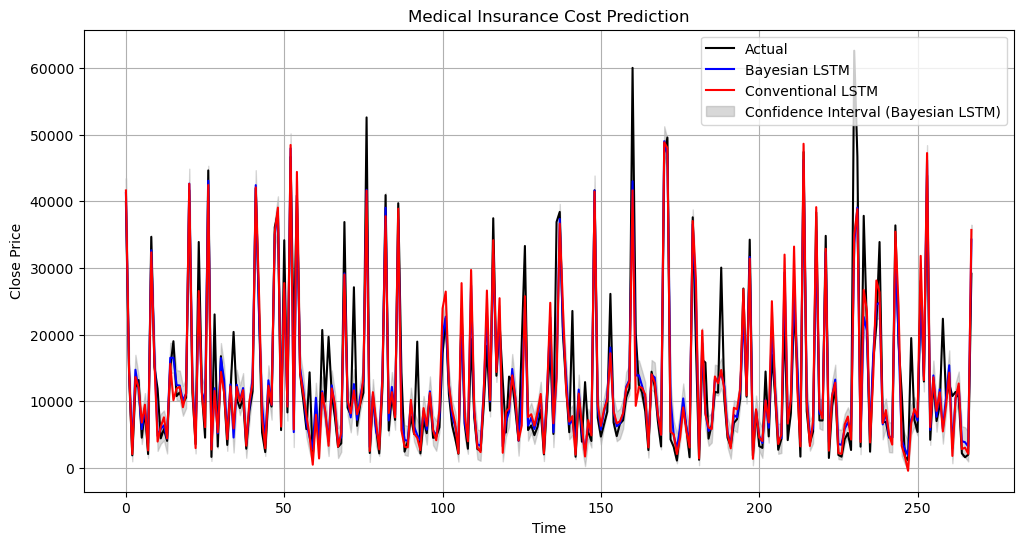

In [48]:
import matplotlib.pyplot as plt
# Plot the predictions and confidence intervals
plt.figure(figsize=(12, 6))
plt.plot(test_target, color='black', label='Actual')
plt.plot(mean_predictions_bayesian, color='blue', label='Bayesian LSTM')
plt.plot(predictions_conventional, color='red', label='Conventional LSTM')
plt.fill_between(
    range(len(test_target)),
    mean_predictions_bayesian - 2 * uncertainty_predictions_bayesian,
    mean_predictions_bayesian + 2 * uncertainty_predictions_bayesian,
    color='gray',
    alpha=0.3,
    label='Confidence Interval (Bayesian LSTM)'
)
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.title('Medical Insurance Cost Prediction')
plt.legend()
plt.grid(True)
plt.show()

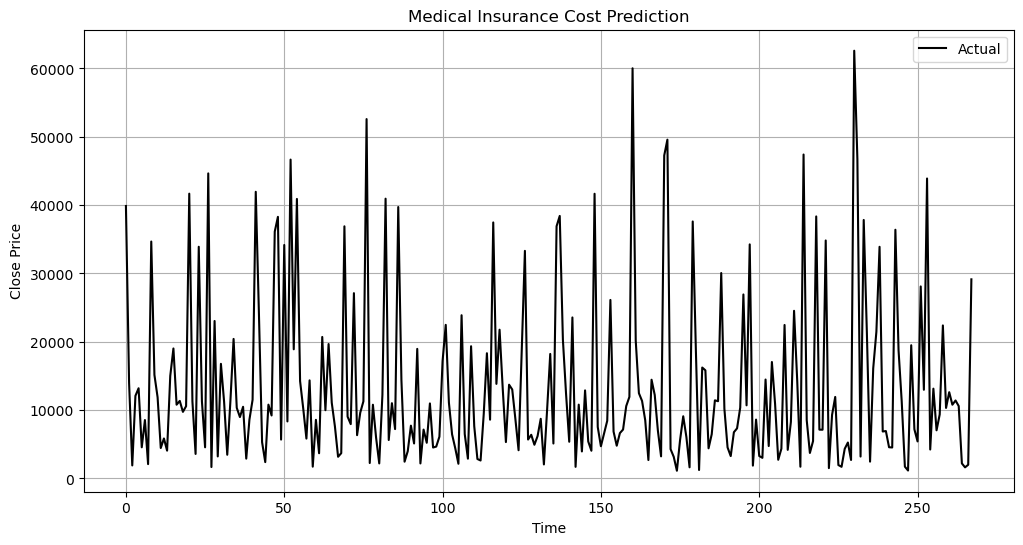

In [49]:
import matplotlib.pyplot as plt

# Plot the actual values
plt.figure(figsize=(12, 6))
plt.plot(test_target, color='black', label='Actual')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.title('Medical Insurance Cost Prediction')
plt.legend()
plt.grid(True)
plt.show()

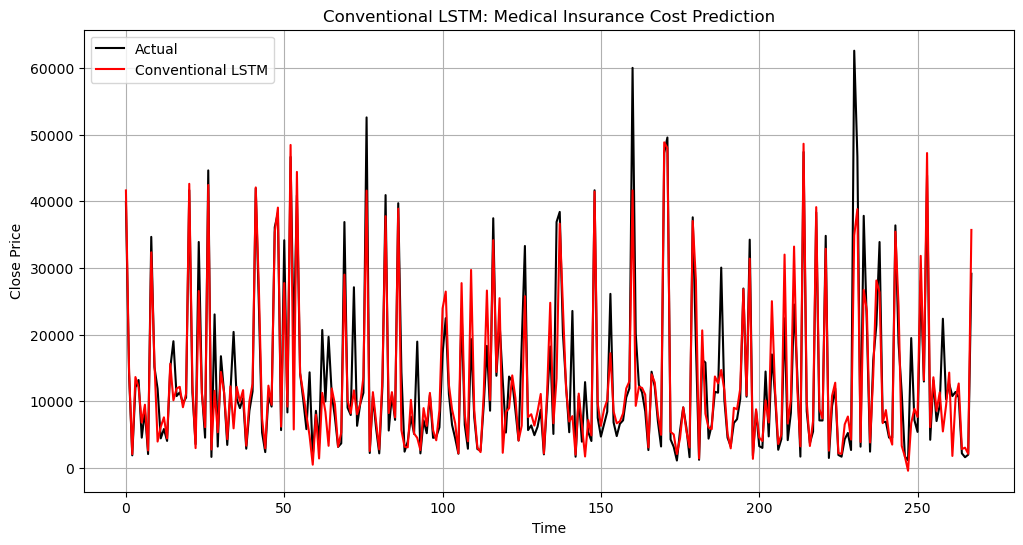

In [50]:
# Plot the predictions for the conventional LSTM model
plt.figure(figsize=(12, 6))
plt.plot(test_target, color='black', label='Actual')
plt.plot(predictions_conventional, color='red', label='Conventional LSTM')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.title('Conventional LSTM: Medical Insurance Cost Prediction')
plt.legend()
plt.grid(True)
plt.show()

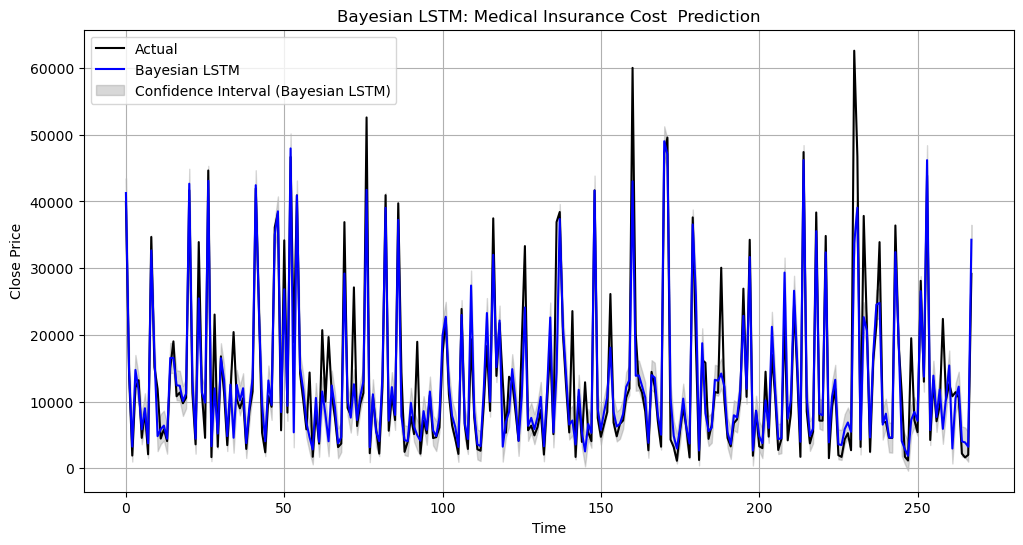

In [51]:
# Plot the predictions and confidence interval for the Bayesian LSTM model
plt.figure(figsize=(12, 6))
plt.plot(test_target, color='black', label='Actual')
plt.plot(mean_predictions_bayesian, color='blue', label='Bayesian LSTM')
plt.fill_between(
    range(len(test_target)),
    mean_predictions_bayesian - 2 * uncertainty_predictions_bayesian,
    mean_predictions_bayesian + 2 * uncertainty_predictions_bayesian,
    color='gray',
    alpha=0.3,
    label='Confidence Interval (Bayesian LSTM)'
)
plt.xlabel('Time')
plt.ylabel('Close c')
plt.title('Bayesian LSTM: Medical Insurance Cost  Prediction')
plt.legend()
plt.grid(True)
plt.show()

In [52]:
# Calculate residuals for the Bayesian LSTM model
residuals_bayesian = test_target - mean_predictions_bayesian

# Calculate residuals for the conventional LSTM model
residuals_conventional = test_target - predictions_conventional

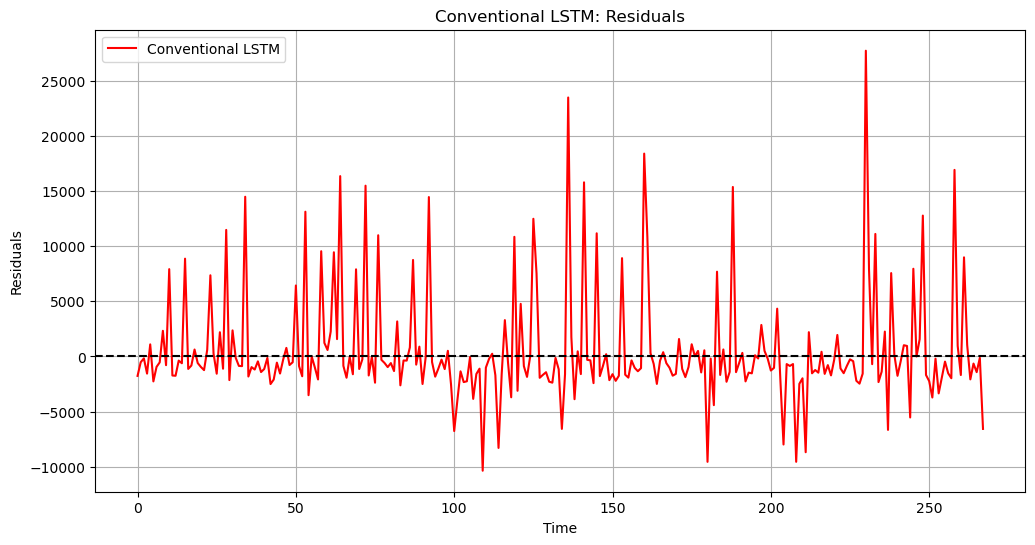

In [53]:
# Plot residuals for the Conventional LSTM model
plt.figure(figsize=(12, 6))
plt.plot(residuals_conventional, color='red', label='Conventional LSTM')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.title('Conventional LSTM: Residuals')
plt.legend()
plt.grid(True)
plt.show()

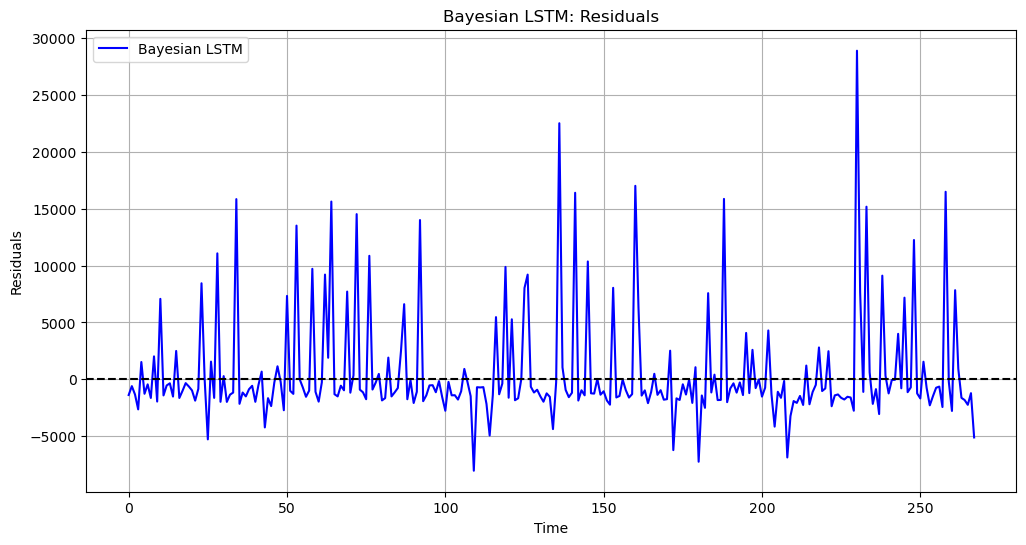

In [54]:
# Plot residuals for the Bayesian LSTM model
plt.figure(figsize=(12, 6))
plt.plot(residuals_bayesian, color='blue', label='Bayesian LSTM')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.title('Bayesian LSTM: Residuals')
plt.legend()
plt.grid(True)
plt.show()

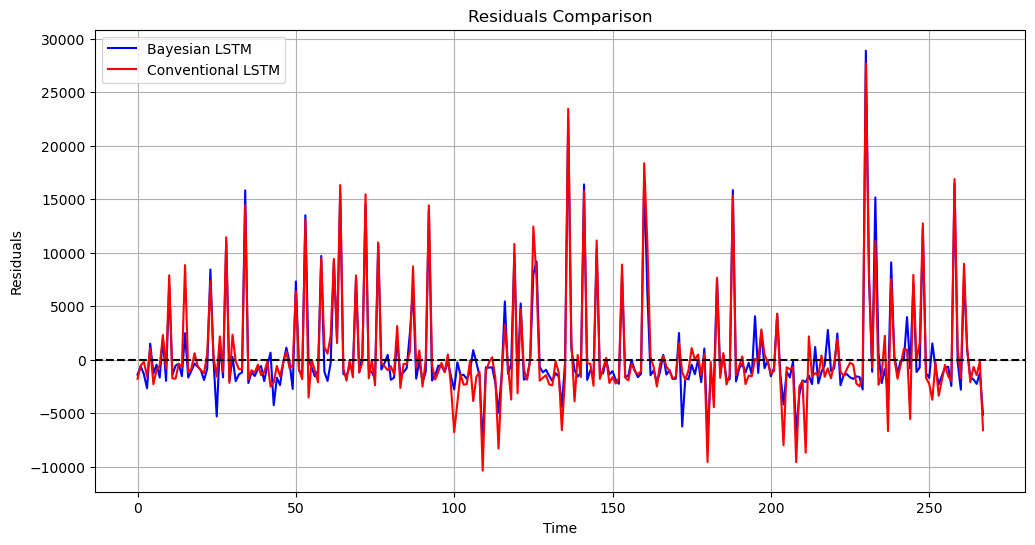

In [55]:
# Plot residuals for both models
plt.figure(figsize=(12, 6))
plt.plot(residuals_bayesian, color='blue', label='Bayesian LSTM')
plt.plot(residuals_conventional, color='red', label='Conventional LSTM')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.title('Residuals Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [56]:
model_bayesian.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 1, 50)               │          11,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1, 50)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 96,155 (375.61 KB)

 Trainable params: 32,051 (125.20 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64,104 (250.41 KB)

In [57]:
predictions = model_bayesian.predict(test_features)
print(predictions[:5])

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[[0.64065844]
 [0.21482143]
 [0.03401852]
 [0.21746051]
 [0.1686989 ]]
